In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12
})

In [46]:
df = pd.read_csv("data/processed_esg_financial_data.csv")

print(df.shape)
df.head()

(11000, 16)


,company_id,company_name,industry,region,year,revenue,profit_margin,market_cap,growth_rate,esg_overall,esg_environmental,esg_social,esg_governance,carbon_emissions,water_usage,energy_consumption
0,1,Company_1,Retail,Latin America,2015,0.002342,0.371429,0.000388,0.552703,0.548108,0.607,0.335,0.768,0.000193,0.000321,0.000038
1,1,Company_1,Retail,Latin America,2016,0.002422,0.351429,0.000422,0.529730,0.544865,0.589,0.328,0.785,0.000203,0.000338,0.000040
2,1,Company_1,Retail,Latin America,2017,0.002926,0.360000,0.000360,0.745946,0.542703,0.576,0.340,0.778,0.000247,0.000411,0.000049
3,1,Company_1,Retail,Latin America,2018,0.002890,0.347143,0.000325,0.471622,0.558919,0.623,0.334,0.783,0.000233,0.000389,0.000046
4,1,Company_1,Retail,Latin America,2019,0.002869,0.355714,0.000620,0.477027,0.543784,0.637,0.300,0.761,0.000228,0.000381,0.000045


In [47]:

df.columns.tolist()

['company_id',
 'company_name',
 'industry',
 'region',
 'year',
 'revenue',
 'profit_margin',
 'market_cap',
 'growth_rate',
 'esg_overall',
 'esg_environmental',
 'esg_social',
 'esg_governance',
 'carbon_emissions',
 'water_usage',
 'energy_consumption']

In [48]:
# Keep only relevant numeric columns
numeric_cols = [
    'revenue', 'profit_margin', 'market_cap', 'growth_rate',
    'esg_overall', 'esg_environmental', 'esg_social', 'esg_governance'
]

df = df[numeric_cols].dropna()

In [49]:
from sklearn.preprocessing import StandardScaler

esg_cols = ['esg_environmental', 'esg_social', 'esg_governance']

scaler = StandardScaler()
df[esg_cols] = scaler.fit_transform(df[esg_cols])

df['ESG_Index'] = df[esg_cols].mean(axis=1)

In [50]:
kpis = {
    "Avg ESG Score": df['ESG_Index'].mean(),
    "Avg Revenue": df['revenue'].mean(),
    "Avg Profit Margin": df['profit_margin'].mean(),
    "Avg Growth Rate": df['growth_rate'].mean(),
    "Avg Market Cap": df['market_cap'].mean()
}

for k, v in kpis.items():
    print(f"{k}: {round(v, 2)}")

Avg ESG Score: -0.0
Avg Revenue: 0.03
Avg Profit Margin: 0.44
Avg Growth Rate: 0.55
Avg Market Cap: 0.02


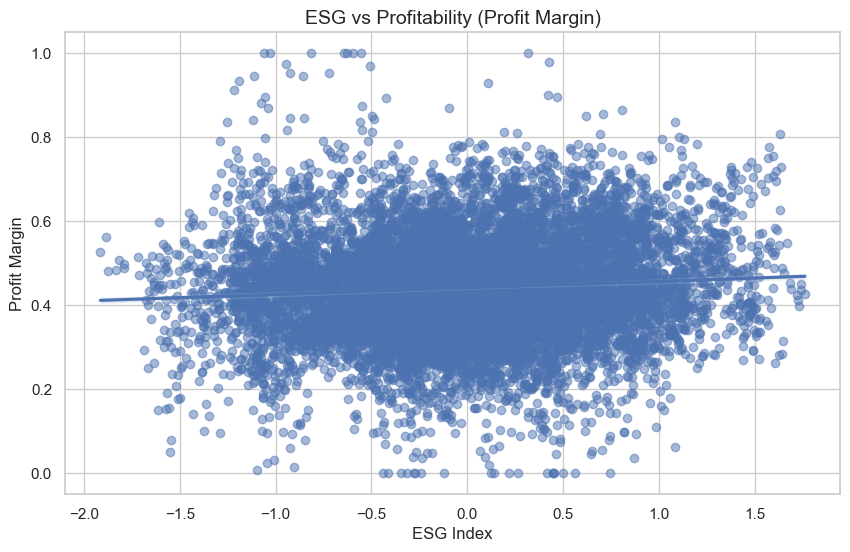

In [51]:

# BUSINESS QUESTION - 1  
# Q1: ESG vs Profitability : Do companies with higher ESG scores perform better financially compared to others?

sns.regplot(
    x='ESG_Index', 
    y='profit_margin', 
    data=df,
    scatter_kws={'alpha':0.5}
)

plt.title("ESG vs Profitability (Profit Margin)")
plt.xlabel("ESG Index")
plt.ylabel("Profit Margin")
plt.show()

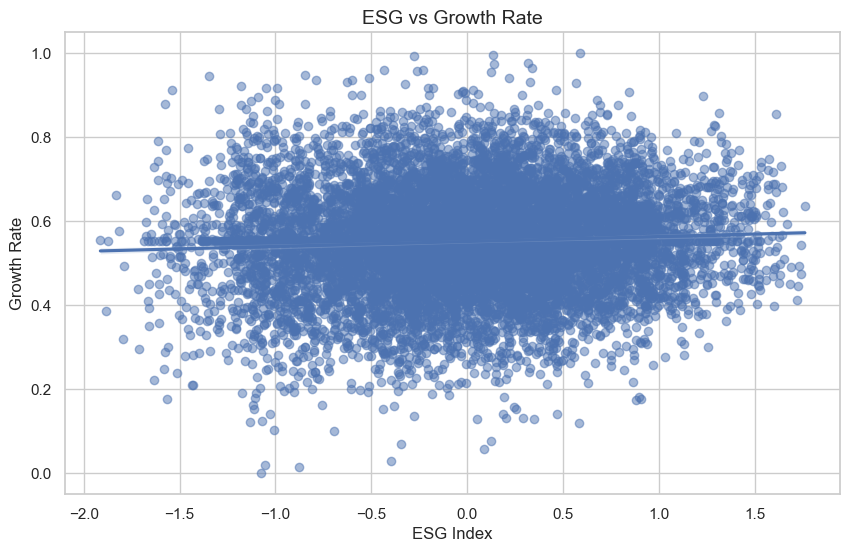

In [52]:
# BUSINESS QUESTION - 2  
# Is there a measurable relationship between ESG performance and revenue growth or profitability?
sns.regplot(
    x='ESG_Index', 
    y='growth_rate', 
    data=df,
    scatter_kws={'alpha':0.5}
)

plt.title("ESG vs Growth Rate")
plt.xlabel("ESG Index")
plt.ylabel("Growth Rate")
plt.show()

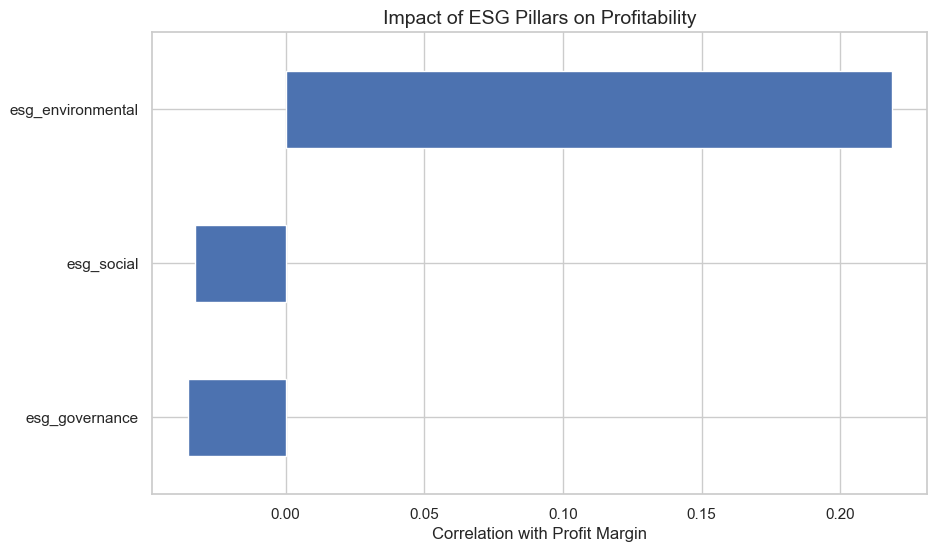

In [ ]:
# BUSINESS QUESTION - 3   
# Which component of ESG (Environmental, Social, or Governance) has the most significant impact on financial performance?
impact_df = df[
    ['esg_environmental', 'esg_social', 'esg_governance', 'profit_margin']
]

corr = impact_df.corr()['profit_margin'].drop('profit_margin')

corr.sort_values().plot(kind='barh')

plt.title("Impact of ESG Pillars on Profitability")
plt.xlabel("Correlation with Profit Margin")
plt.show()

In [ ]:
# BUSINESS QUESTION - 4  
# How does social responsibility (employee satisfaction, diversity, etc.) influence company performance?

df['profit_risk_proxy'] = abs(df['profit_margin'] - df['profit_margin'].mean())

sns.barplot(
    x='esg_governance', 
    y='profit_risk_proxy', 
    data=df
)

plt.title("Governance vs Financial Stability (Risk Proxy)")
plt.xlabel("Governance Score")
plt.ylabel("Profit Variability")
plt.show()

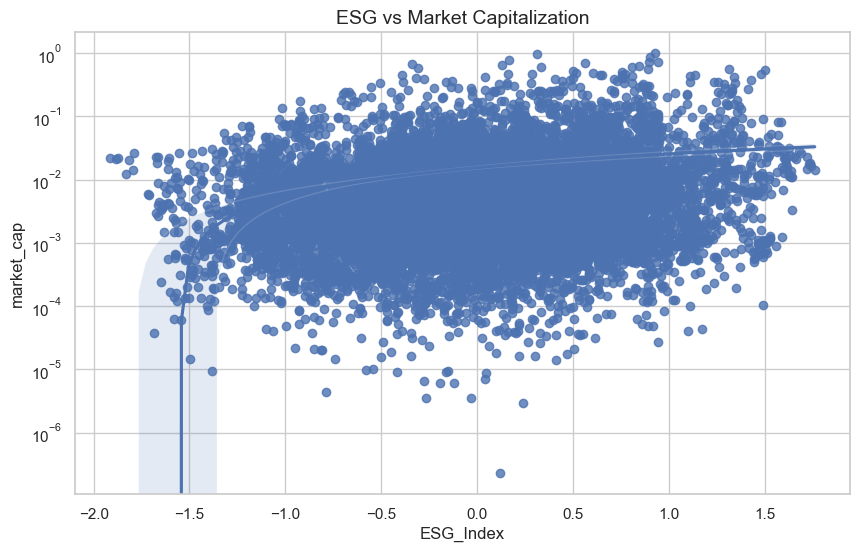

In [41]:
# BUSINESS QUESTION - 5  
# Is there a correlation between ESG scores and market valuation (market cap)?
sns.regplot(
    x='ESG_Index', 
    y='market_cap', 
    data=df
)

plt.yscale('log')
plt.title("ESG vs Market Capitalization")
plt.show()

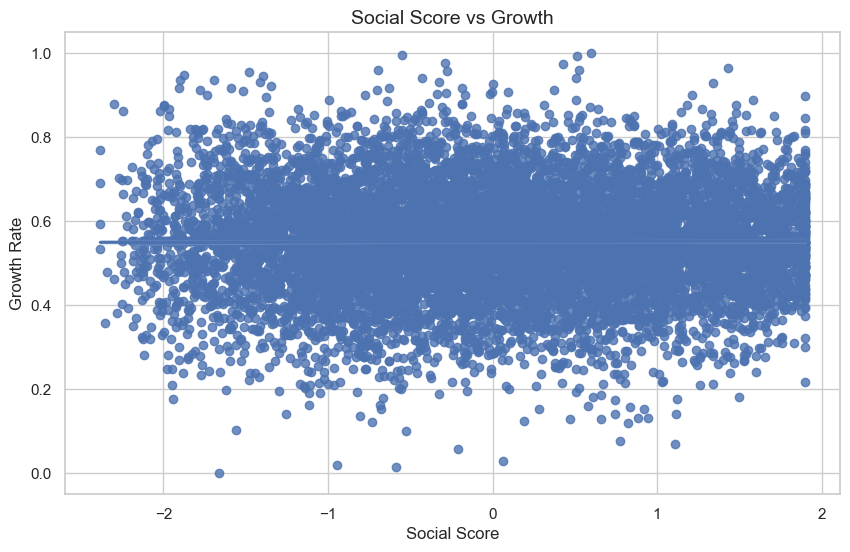

In [56]:
#Q5: Social Impact
sns.regplot(
    x='esg_social', 
    y='growth_rate', 
    data=df
)

plt.title("Social Score vs Growth")
plt.xlabel("Social Score")
plt.ylabel("Growth Rate")
plt.show()

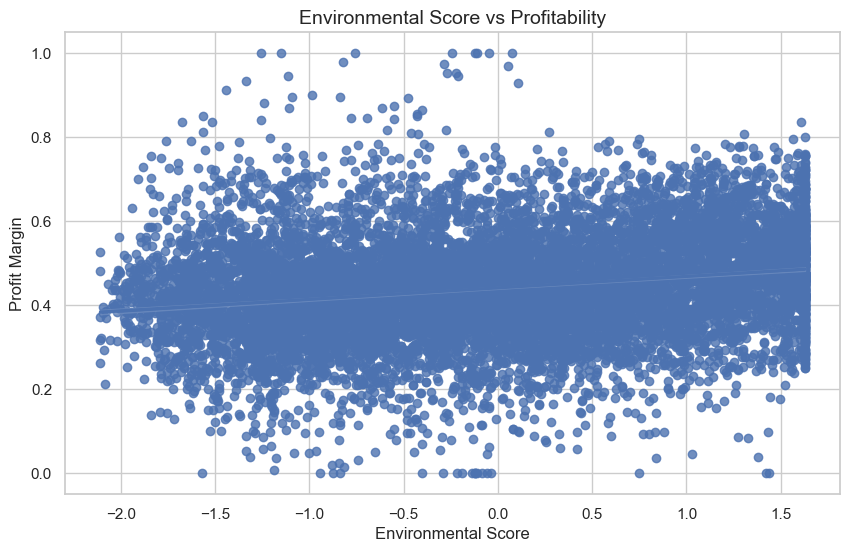

In [57]:
#Q6: Environmental Efficiency
sns.regplot(
    x='esg_environmental', 
    y='profit_margin', 
    data=df
)

plt.title("Environmental Score vs Profitability")
plt.xlabel("Environmental Score")
plt.ylabel("Profit Margin")
plt.show()

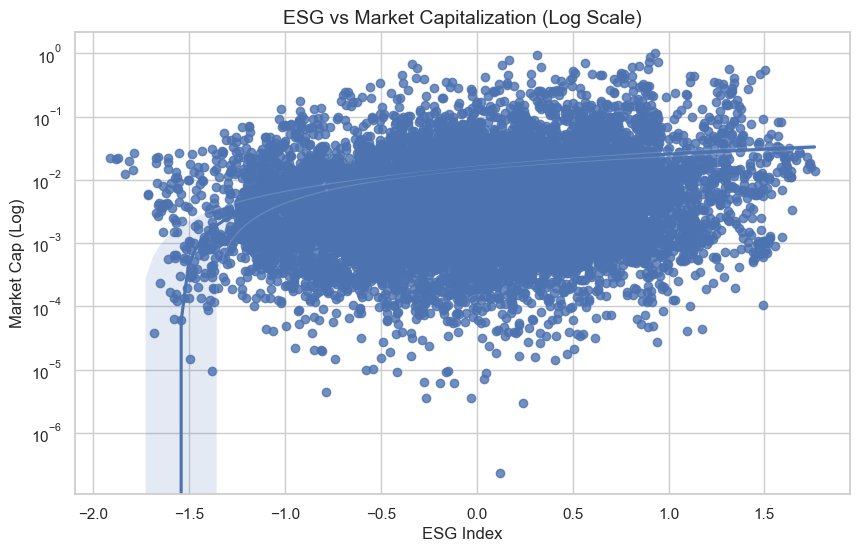

In [59]:
# BUSINESS QUESTION 
# Q7: ESG vs Market Valuation
sns.regplot(
    x='ESG_Index', 
    y='market_cap', 
    data=df
)

plt.yscale('log')
plt.title("ESG vs Market Capitalization (Log Scale)")
plt.xlabel("ESG Index")
plt.ylabel("Market Cap (Log)")
plt.show()

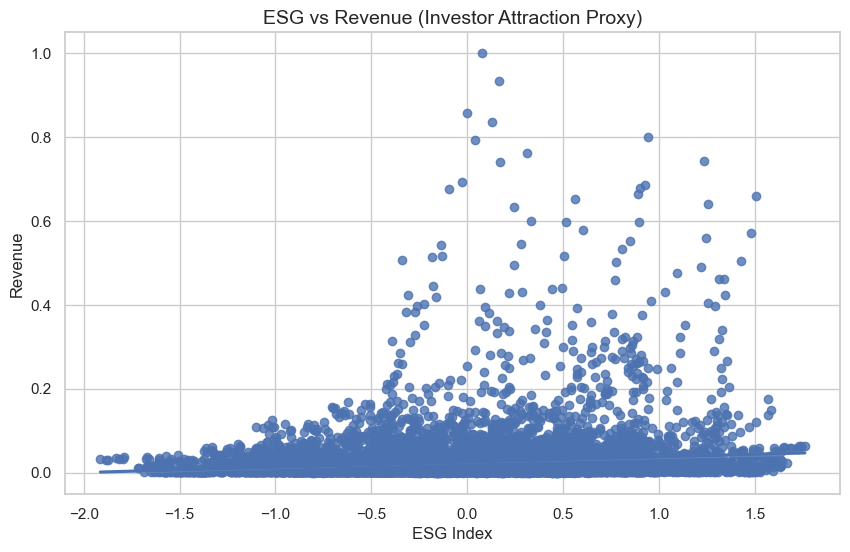

In [60]:
#Q8: Investor Attraction
sns.regplot(
    x='ESG_Index', 
    y='revenue', 
    data=df
)

plt.title("ESG vs Revenue (Investor Attraction Proxy)")
plt.xlabel("ESG Index")
plt.ylabel("Revenue")
plt.show()

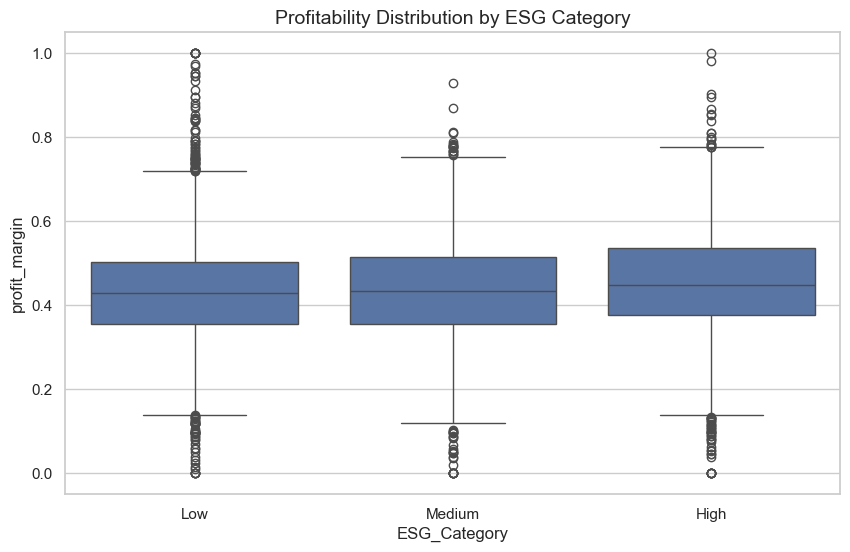

In [61]:
# BUSINESS QUESTION -
#ESG Segmentation 

df['ESG_Category'] = pd.qcut(
    df['ESG_Index'], 
    3, 
    labels=['Low', 'Medium', 'High']
)

sns.boxplot(
    x='ESG_Category', 
    y='profit_margin', 
    data=df
)

plt.title("Profitability Distribution by ESG Category")
plt.show()

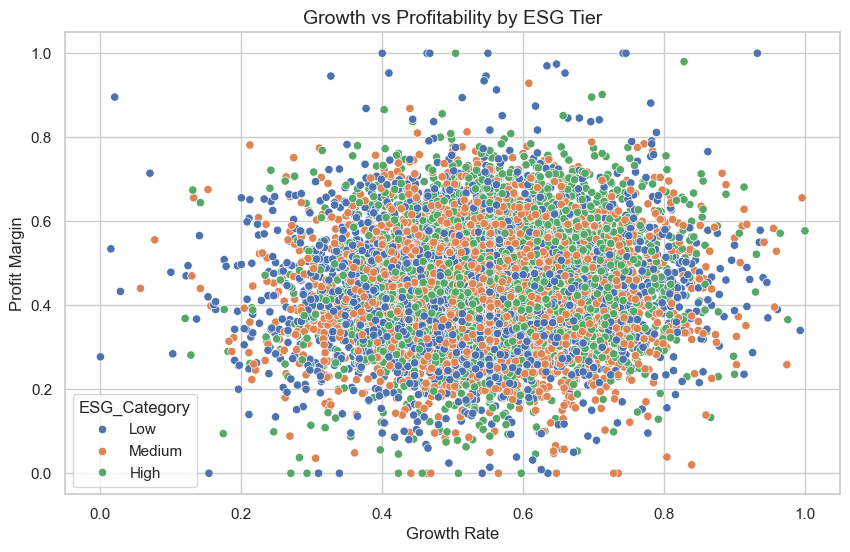

In [62]:
#Q9: Sustainability (Growth vs Profit Balance)
sns.scatterplot(
    x='growth_rate',
    y='profit_margin',
    hue='ESG_Category',
    data=df
)

plt.title("Growth vs Profitability by ESG Tier")
plt.xlabel("Growth Rate")
plt.ylabel("Profit Margin")
plt.show()

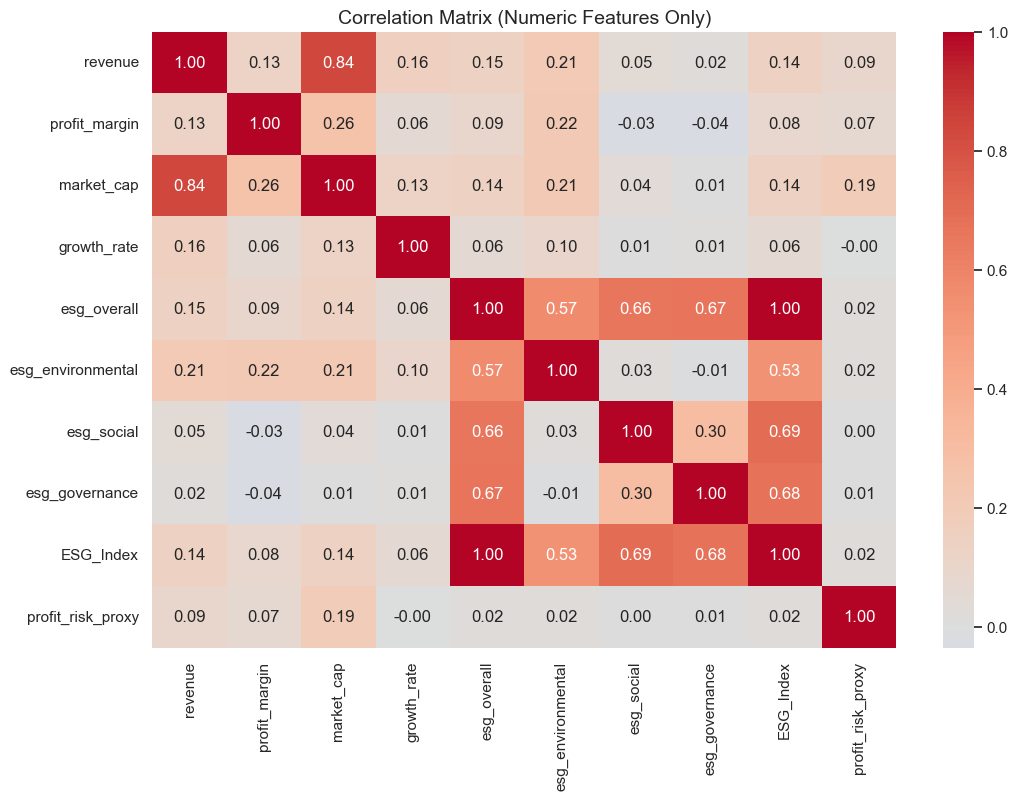

In [64]:
# Q10: Investment View (Correlation Matrix)

# Select only numeric columns safely
corr_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_df.corr(),
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix (Numeric Features Only)")
plt.show()